# Noise-gen: real vs. generated, side-by-side

Loads the trained `PositionalHarmonicNoiseGen` (the *swapped* run) and the **full
DREGON / Michael's recordings as `TimeFrame`s**. Pick any recording and any
`(start, duration)` window — the notebook slices the recording, feeds its RPS +
array geometry through the model, and shows the **real** noise slice next to the
**generated** one (spectrograms, waveforms, RPS, multi-scale-STFT loss, and audio
players).

No `TimeFrameNoisePool` — you slice arbitrary windows of the original recordings
directly.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import Audio, display

from data_processing.dregon import load_dregon_timeframes
from data_processing.michaels import load_michaels_timeframes
from data_processing.frames import get_meta
from data_processing.online_mixing import _extract_audio_array, interpolate_rps_to_stft_grid
from models.registry import (
    NOISE_GEN_MODEL_REGISTRY,
    build_noise_gen_loss,
    build_noise_gen_model,
)
from tasks.noise_generation import DroneCodebook, geometry_to_rel_pos

SR = 16000
DEVICE = "cpu"  # 1 s slices render fine on CPU; set "cuda:0" if you prefer
CKPT = PROJECT_ROOT / "results/noise_gen_dregon_michaels_swapped/best_positional_harmonic_gen.pt"
print("checkpoint:", CKPT)

checkpoint: /home/flyingleafe/Research/PhD/projects/harmonic-noise-suppression/results/noise_gen_dregon_michaels_swapped/best_positional_harmonic_gen.pt


In [2]:
# --- load model + external codebook from the bundle -------------------------------
bundle = torch.load(CKPT, map_location=DEVICE, weights_only=False)
print("bundle keys:", list(bundle), "| cond_dim:", bundle["cond_dim"], "| drones:", bundle["drone_names"])

# The historical swapped-run bundle stores the *bare* conditioned generator
# (state-dict keys ``emitter.*``) plus its DroneCodebook as a separate entry, so
# build the generator straight from the registry factory. (The newer composite
# ``build_noise_gen_model`` — used by the E6 variant-comparison section below —
# folds the codebook into the model; both restore the same weights.)
model = NOISE_GEN_MODEL_REGISTRY["positional_harmonic_gen"](
    sample_rate=SR, n_harmonics=100, cond_dim=bundle["cond_dim"]
)
model.load_state_dict(bundle["model"])
model.to(DEVICE).eval()

codebook = DroneCodebook(bundle["cond_dim"], names=bundle["drone_names"]).to(DEVICE)
codebook.load_state_dict(bundle["codebook"])

# multi-scale STFT loss, matching the training default (for a quantitative number)
loss_fn = build_noise_gen_loss(
    stft_sizes=[2048, 1024, 512, 256, 128], log_weight=1.0, loss_type="L1",
).to(DEVICE)
print("params:", sum(p.numel() for p in model.parameters()))

bundle keys: ['model', 'codebook', 'cond_dim', 'drone_names'] | cond_dim: 16 | drones: ['dregon', 'michaels']
params: 245824


In [3]:
# --- load the FULL recordings as TimeFrames (sliced arbitrarily below) ------------
# DREGON in_flight_noise (8ch, no download) + Michael's FLY124/FLY125.
_dregon = load_dregon_timeframes(
    PROJECT_ROOT / "data", splits=["in_flight_noise"], target_sr=SR, download=False
)
_michaels = load_michaels_timeframes(data_root=PROJECT_ROOT / "data", sr=SR)

RECORDINGS = {}  # friendly id -> {"tf", "drone"}
for tf in _dregon:
    RECORDINGS[f"dregon:{get_meta(tf, 'recording_id')}"] = {"tf": tf, "drone": "dregon"}
for tf in _michaels:
    RECORDINGS[f"michaels:FLY{get_meta(tf, 'recording_id')}"] = {"tf": tf, "drone": "michaels"}

print(f"{'recording id':45s} {'drone':9s} {'dur (s)':>8s}  rps mean (4 rotors)")
print("-" * 95)
for rid, e in RECORDINGS.items():
    tf = e["tf"]
    dur = tf["audio"].t_end - tf["audio"].t_start
    rps_mean = interpolate_rps_to_stft_grid(tf, n_frames=64, hop_length=int(dur * SR / 64)).mean(1)
    print(f"{rid:45s} {e['drone']:9s} {dur:8.1f}  {np.round(rps_mean, 1)}")

recording id                                  drone      dur (s)  rps mean (4 rotors)
-----------------------------------------------------------------------------------------------
dregon:free-flight_nosource_room1             dregon        71.1  [73.6 64.8 72.9 64.1]
dregon:free-flight_nosource_room2             dregon        81.6  [75.1 68.  73.4 70.5]
dregon:hovering_nosource_room2                dregon        44.9  [68.3 62.7 67.2 66.6]
dregon:updown_nosource_room2                  dregon        53.8  [74.2 69.1 73.1 72.5]
dregon:rectangle_nosource_room2               dregon        44.4  [68.6 62.9 66.9 65.1]
dregon:spinning_nosource_room2                dregon        40.6  [64.3 59.9 62.4 62.9]
michaels:FLY124                               michaels     121.6  [64.1 54.3 59.7 55.9]
michaels:FLY125                               michaels     177.5  [82.  67.4 75.  68.8]


/home/flyingleafe/Research/PhD/projects/harmonic-noise-suppression/src/data_processing/michaels.py:144: DtypeWarning: Columns (49,50,211,215,216,217,227) have mixed types. Specify dtype option on import or set low_memory=False.
  csv = pd.read_csv(csv_path)


In [4]:
# --- core: slice a recording window and render the model's noise ------------------
def render_slice(rec_id: str, start_s: float, dur_s: float = 1.0):
    """Slice [start_s, start_s+dur_s] of a recording (start_s relative to its start)
    and return the real target, the generated noise, and the conditioning RPS."""
    e = RECORDINGS[rec_id]
    tf, drone = e["tf"], e["drone"]
    t0 = tf["audio"].t_start
    avail = tf["audio"].t_end - t0
    if start_s < 0 or start_s + dur_s > avail:
        raise ValueError(f"{rec_id}: window [{start_s}, {start_s + dur_s}] outside [0, {avail:.1f}] s")

    sl = tf.time[t0 + start_s : t0 + start_s + dur_s]
    n = int(round(dur_s * SR))
    target = _extract_audio_array(sl, target_len=n)                      # (M, T)
    rps = interpolate_rps_to_stft_grid(sl, n_frames=n, hop_length=1)     # (R, T) at audio rate
    rel = geometry_to_rel_pos(sl["mic_pos"].data, sl["rotor_pos"].data)[: target.shape[0]]  # (M,R,3)

    z = codebook([drone])
    with torch.no_grad():
        pred = model(
            torch.from_numpy(rps)[None].to(DEVICE),
            torch.from_numpy(rel)[None].to(DEVICE),
            z,
        )[0].cpu().numpy()                                               # (M, T)
        # mic axis folded into batch, exactly like training
        loss = loss_fn(
            torch.from_numpy(pred).to(DEVICE), torch.from_numpy(target).to(DEVICE)
        ).item()
    return {
        "rec_id": rec_id, "drone": drone, "start_s": start_s, "dur_s": dur_s,
        "target": target, "pred": pred, "rps": rps, "rel": rel, "loss": loss,
    }


def _logspec(x, n_fft=1024, hop=256):
    X = torch.stft(torch.from_numpy(np.ascontiguousarray(x)).float(), n_fft=n_fft, hop_length=hop,
                   window=torch.hann_window(n_fft), return_complex=True)
    return 20 * np.log10(np.abs(X.numpy()) + 1e-6)


def compare(rec_id: str, start_s: float, dur_s: float = 1.0, mic: int = 0):
    """Plot real vs generated noise for one mic, plus RPS, and return audio players."""
    r = render_slice(rec_id, start_s, dur_s)
    tgt, prd, rps = r["target"][mic], r["pred"][mic], r["rps"]
    St, Sp = _logspec(tgt), _logspec(prd)
    vmax = max(St.max(), Sp.max()); vmin = vmax - 80

    fig, ax = plt.subplots(2, 2, figsize=(14, 7))
    fig.suptitle(f"{rec_id}  ({r['drone']})  t=[{start_s:.1f},{start_s+dur_s:.1f}] s  mic {mic}"
                 f"  |  msSTFT loss={r['loss']:.3f}", fontsize=12)
    for a, S, ttl in [(ax[0, 0], St, "REAL noise"), (ax[0, 1], Sp, "GENERATED noise")]:
        im = a.imshow(S, origin="lower", aspect="auto", vmin=vmin, vmax=vmax, cmap="magma",
                      extent=[0, dur_s, 0, SR / 2])
        a.set_title(ttl); a.set_ylabel("Hz"); a.set_xlabel("s")
        fig.colorbar(im, ax=a, format="%+0.0f dB")

    t = np.arange(len(tgt)) / SR
    ax[1, 0].plot(t, tgt, lw=0.5, label="real")
    ax[1, 0].plot(t, prd, lw=0.5, alpha=0.7, label="generated")
    ax[1, 0].set_title("waveform"); ax[1, 0].set_xlabel("s"); ax[1, 0].legend(loc="upper right")

    tr = np.arange(rps.shape[1]) / SR
    for i in range(rps.shape[0]):
        ax[1, 1].plot(tr, rps[i], lw=1.0, label=f"rotor {i}")
    ax[1, 1].set_title("conditioning RPS"); ax[1, 1].set_xlabel("s"); ax[1, 1].set_ylabel("Hz")
    ax[1, 1].legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()

    print("REAL:");      display(Audio(tgt, rate=SR, normalize=True))
    print("GENERATED:"); display(Audio(prd, rate=SR, normalize=True))
    return r

### Example — DREGON
Edit `rec_id`, `start_s`, `dur_s`, `mic` and re-run.

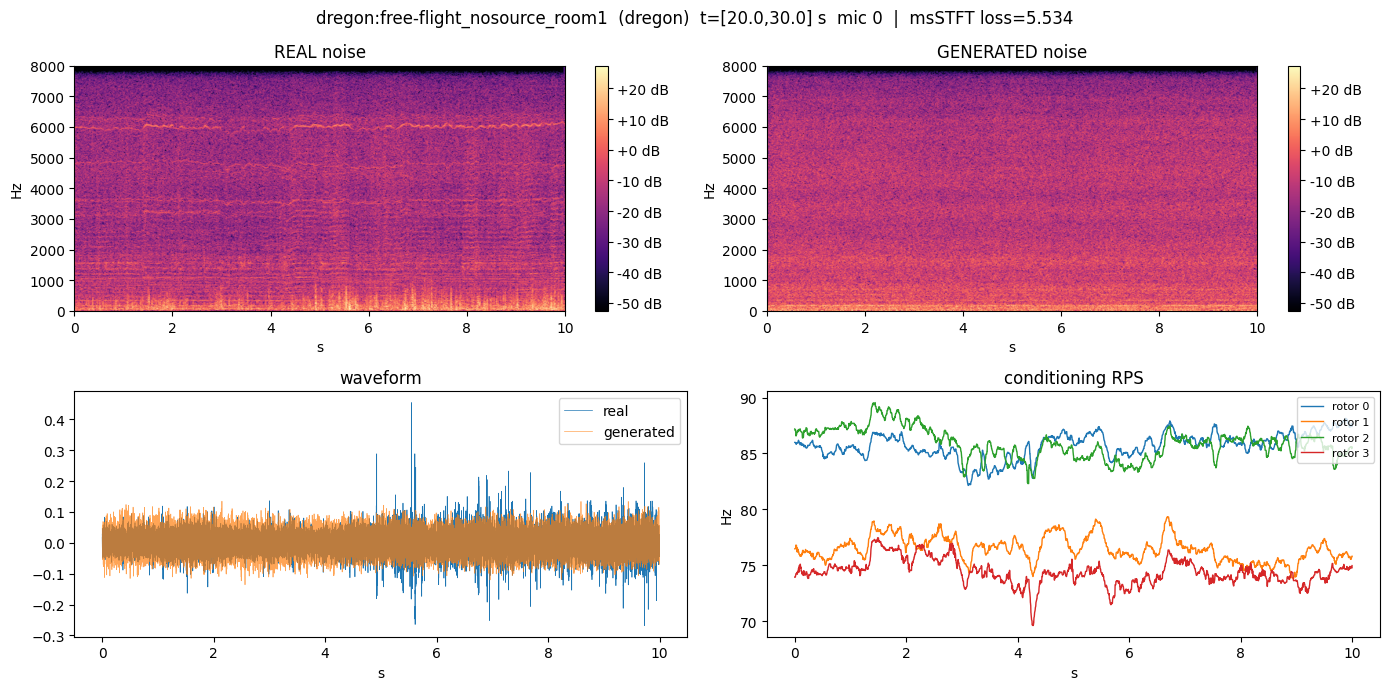

REAL:


GENERATED:


In [5]:
_ = compare("dregon:free-flight_nosource_room1", start_s=20.0, dur_s=10.0, mic=0)

### Example — Michael's (DJI Matrice 100)

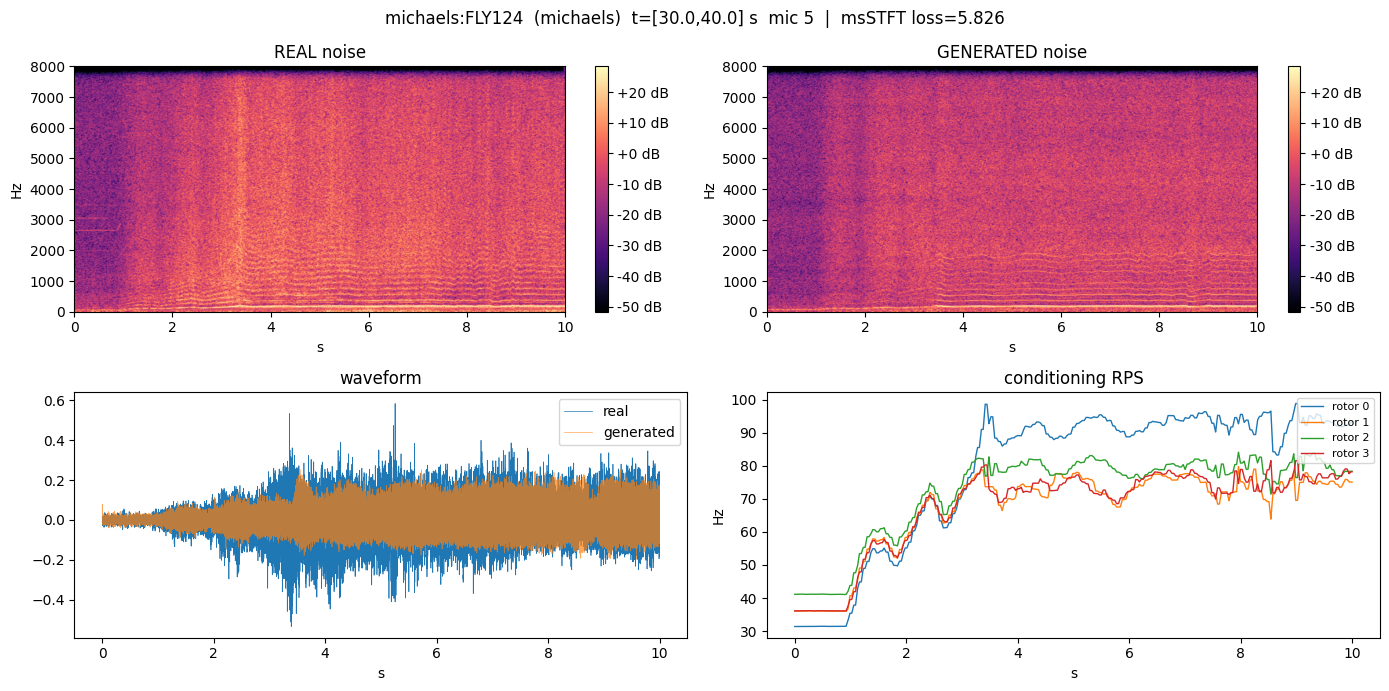

REAL:


GENERATED:


In [6]:
_ = compare("michaels:FLY124", start_s=30.0, dur_s=10.0, mic=5)

### Notes

- `start_s` is **relative to each recording's start**; valid range is `[0, dur]`
  from the inventory table above.
- `render_slice(...)` returns the raw arrays (`target`, `pred` `(M, T)`; `rps`
  `(R, T)`) if you want to do your own analysis or compare other mics.
- The model was conditioned per-drone via the external `DroneCodebook`
  (`codebook([drone])`). Loading the bundle restores both codes.
- Loss is the same multi-scale STFT magnitude loss used in training (mic axis
  folded into the batch); it is blind to a common delay but sees inter-rotor delay
  structure.

# Generator-variant comparison (E6): the linewidth ablation

The three **E6** generator arms differ *only* in how they broaden harmonic
lines ("linewidth"):

- **`baseline`** — clean oscillator bank (only the always-on per-harmonic
  initial-phase randomisation).
- **`randphase`** — STFT phase scrambling of the harmonic bank
  (`use_random_phases=True`): a *constant* ~30 Hz linewidth, harmonic
  coherence destroyed.
- **`jitter`** — Ornstein–Uhlenbeck perturbation of the conditioning RPS
  *inside* the emitter (σ=0.6 rev/s, τ=16 ms): coherent,
  **frequency-proportional** broadening (harmonic k spread by ±k·σ Hz) — the
  physically-motivated fix for the mid-k "harmonic washout". Rendered with
  `rps_jitter=True` (the broadening is OFF at eval by default).

Motivation: `docs/experiments/rps-trajectory-refinement.md` (§ jitter
linewidth) and `conf/experiment/e6_noisegen_*.md`.

**Checkpoints** are parameterised in `VARIANTS` below (`best.ckpt` per arm).
Only `randphase` has finished so far; `baseline`/`jitter` are skipped with a
note and picked up automatically on re-execution once their jobs land. Each
arm is a composite `build_noise_gen_model` state-dict (generator + its
`DroneCodebook`); build kwargs per arm mirror the matching
`conf/model/positional_harmonic_gen_cond*.yaml`.

**Data / split.** Same real recordings and RPS conditioning as the sections
above, but windows come from the **held-out validation region** of the
`val_at_start=true` swapped split (`val_pct=0.1` ⇒ the first 10 % of each
recording's time axis). Caveat for **DREGON**: its held-out region is
*takeoff only* — measured telemetry does not spin up until ≈5.5 s while the
val cut sits at 7.1 s, so no stable in-flight RPS trajectory exists there. The
DREGON panel therefore uses an in-flight (in-train) window purely for the
visual linewidth story; **Michael's FLY124** (low idle throttle, but fully
telemetry-covered inside its val region) carries the genuinely out-of-train
comparison.

Each per-drone subsection shows: (1) a **spectrogram gallery**
(real | arms, shared scale, 0–4 kHz); (2) a **zoomed line-shape panel** around
harmonics k≈20–30; (3) a **comb-masked spectral-error** table + bar chart
(mean |Δ log-mag| along the k·r(t) tracks, per k-band, plus the plain msSTFT
distance).

In [7]:
# --- E6 variant checkpoints (parameterised — re-run to pick up newly-finished arms) ---
DRONES = ["dregon", "michaels"]

# name -> best.ckpt (a composite build_noise_gen_model state_dict: generator + codebook)
VARIANTS = {
    "baseline":  PROJECT_ROOT / "omnirun-outputs/r2-artifacts/e6_noisegen_baseline_best.ckpt",
    "randphase": PROJECT_ROOT / "omnirun-outputs/python-72109e/results/e6_noisegen_randphase/best.ckpt",
    "jitter":    PROJECT_ROOT / "omnirun-outputs/r2-artifacts/e6_noisegen_jitter_best.ckpt",
    "jitter_latreg": PROJECT_ROOT / "omnirun-outputs/r2-artifacts/e6_noisegen_jitter_latreg_best.ckpt",
}
# per-arm generator build kwargs — must match conf/model/positional_harmonic_gen_cond*.yaml
VARIANT_BUILD = {
    "baseline":  dict(),
    "randphase": dict(use_random_phases=True),
    "jitter":    dict(rps_jitter_sigma=0.6, rps_jitter_tau=0.016),
    "jitter_latreg": dict(rps_jitter_sigma=0.6, rps_jitter_tau=0.016, z_noise_std=0.1, film_spectral_norm=True),
}
# arms whose whole point is a train-time broadening that is OFF at eval by
# default => render them with rps_jitter=True to expose it.
RENDER_JITTER = {"baseline": False, "randphase": False, "jitter": True, "jitter_latreg": True}


def load_variant(name):
    """Rebuild the composite (generator + DroneCodebook) for one arm and load its
    best.ckpt. Missing checkpoints (job still running) are skipped with a note."""
    p = Path(VARIANTS[name])
    if not p.exists():
        print(f"  [skip] {name}: {p.relative_to(PROJECT_ROOT)} not found (job still running?)")
        return None
    sd = torch.load(p, map_location=DEVICE, weights_only=False)
    m = build_noise_gen_model(
        "positional_harmonic_gen", sample_rate=SR, n_harmonics=100,
        cond_dim=16, drone_names=DRONES, **VARIANT_BUILD[name],
    )
    m.load_state_dict(sd, strict=True)
    return m.to(DEVICE).eval()  # eval() => deterministic phases


VARIANT_MODELS = {name: load_variant(name) for name in VARIANTS}
AVAILABLE = [n for n, m in VARIANT_MODELS.items() if m is not None]
print("available variants:", AVAILABLE)

available variants: ['baseline', 'randphase', 'jitter', 'jitter_latreg']


In [8]:
# --- helpers: render every available arm on one real RPS window, then measure ------
# window per recording: (start_s, dur_s). Edit freely.
WINDOWS = {
    "dregon:free-flight_nosource_room1": (20.0, 4.0),  # in-flight (see note above)
    "michaels:FLY124": (4.0, 4.0),                      # held-out val region, out-of-train
}


def render_variants(rec_id, start_s, dur_s=4.0, mic=0):
    """Render the shared real RPS window through every available arm.
    Returns {"target","rps","drone",..., name: pred (M,T) | None}."""
    e = RECORDINGS[rec_id]
    tf, drone = e["tf"], e["drone"]
    t0 = tf["audio"].t_start
    sl = tf.time[t0 + start_s : t0 + start_s + dur_s]
    n = int(round(dur_s * SR))
    target = _extract_audio_array(sl, target_len=n)                   # (M, T)
    rps = interpolate_rps_to_stft_grid(sl, n_frames=n, hop_length=1)  # (R, T) audio-rate
    rel = geometry_to_rel_pos(sl["mic_pos"].data, sl["rotor_pos"].data)[: target.shape[0]]
    rps_t = torch.from_numpy(rps)[None].to(DEVICE).float()
    rel_t = torch.from_numpy(rel)[None].to(DEVICE).float()
    out = {"rec_id": rec_id, "drone": drone, "start_s": start_s, "dur_s": dur_s,
           "mic": mic, "target": target, "rps": rps}
    for name, m in VARIANT_MODELS.items():
        if m is None:
            out[name] = None
            continue
        with torch.no_grad():
            # jitter arm: expose the (eval-off-by-default) OU broadening.
            jitter = True if RENDER_JITTER[name] else None
            out[name] = m(rps_t, rel_t, [drone], rps_jitter=jitter)[0].cpu().numpy()
    return out


COMB_BANDS = {"k<10": range(1, 10), "10-25": range(10, 25), "25-40": range(25, 40)}


def comb_error(target, pred, rps, mic=0, n_fft=1024, hop=256):
    """Mean |Δ log-magnitude| between real and generated, sampled along every
    harmonic comb track k·r_rotor(t) placed from the telemetry RPS, per k-band."""
    St, Sp = _logspec(target[mic], n_fft, hop), _logspec(pred[mic], n_fft, hop)
    n_bins, n_t = St.shape
    rf = rps[:, ::hop][:, :n_t]                          # (R, T') rps on the spec grid
    if rf.shape[1] < n_t:
        rf = np.pad(rf, ((0, 0), (0, n_t - rf.shape[1])), mode="edge")
    res = {}
    for band, ks in COMB_BANDS.items():
        errs = []
        for k in ks:
            for ridx in range(rf.shape[0]):
                bins = np.round(k * rf[ridx] * n_fft / SR).astype(int)
                valid = (bins > 0) & (bins < n_bins)
                if valid.sum():
                    tt = np.arange(n_t)[valid]
                    errs.append(np.abs(St[bins[valid], tt] - Sp[bins[valid], tt]))
        res[band] = float(np.concatenate(errs).mean()) if errs else float("nan")
    return res


def ms_stft(target, pred):
    """Plain multi-scale STFT distance (the training loss), mic axis in batch."""
    return loss_fn(torch.from_numpy(pred).to(DEVICE),
                   torch.from_numpy(target).to(DEVICE)).item()

In [9]:
# --- figures: spectrogram gallery, zoomed line-shape, comb-error table + bars ------
def _band_bins(n_fft, fmax):
    return int(fmax / (SR / n_fft))


def spectrogram_gallery(r, fmax=4000, n_fft=1024, hop=256):
    """real | <available arms>, same RPS input, shared colour scale, 0..fmax Hz."""
    cols = ["real"] + AVAILABLE
    mic = r["mic"]
    Ss = {"real": _logspec(r["target"][mic], n_fft, hop)}
    for n in AVAILABLE:
        Ss[n] = _logspec(r[n][mic], n_fft, hop)
    nb = _band_bins(n_fft, fmax)
    vmax = Ss["real"][:nb].max(); vmin = vmax - 80  # shared scale, keyed to real
    fig, ax = plt.subplots(1, len(cols), figsize=(3.6 * len(cols), 4), squeeze=False)
    for j, c in enumerate(cols):
        ttl = c + (" (rps_jitter)" if RENDER_JITTER.get(c) else "")
        ax[0, j].imshow(Ss[c][:nb], origin="lower", aspect="auto", vmin=vmin, vmax=vmax,
                        cmap="magma", extent=[0, r["dur_s"], 0, fmax])
        ax[0, j].set_title(ttl); ax[0, j].set_xlabel("s")
    ax[0, 0].set_ylabel("Hz")
    fig.suptitle(f"{r['rec_id']}  ({r['drone']})  spectrogram gallery  (mic {mic})")
    plt.tight_layout(); plt.show()


def lineshape_panel(r, k_center=25, half_bw_hz=150, n_fft=4096, hop=512):
    """Time-averaged magnitude spectrum in a ~300 Hz band around harmonic
    k_center of the mean fundamental — the linewidth story made visible."""
    mic = r["mic"]
    r0 = float(r["rps"].mean())            # mean fundamental across rotors & time
    fc = k_center * r0
    freqs = np.arange(n_fft // 2 + 1) * SR / n_fft
    band = (freqs >= fc - half_bw_hz) & (freqs <= fc + half_bw_hz)

    def avg_mag_db(x):
        X = torch.stft(torch.from_numpy(np.ascontiguousarray(x)).float(), n_fft=n_fft,
                       hop_length=hop, window=torch.hann_window(n_fft), return_complex=True)
        return 20 * np.log10(np.abs(X.numpy()).mean(1) + 1e-6)

    fig, axp = plt.subplots(figsize=(11, 4))
    axp.plot(freqs[band], avg_mag_db(r["target"][mic])[band], "k", lw=2.0, label="real")
    for n in AVAILABLE:
        axp.plot(freqs[band], avg_mag_db(r[n][mic])[band], lw=1.4, alpha=0.85,
                 label=n + (" (jit)" if RENDER_JITTER.get(n) else ""))
    axp.set_title(f"{r['rec_id']}  line shape around k≈{k_center} "
                  f"(f≈{fc:.0f} Hz, r̄={r0:.1f} Hz)")
    axp.set_xlabel("Hz"); axp.set_ylabel("time-avg magnitude (dB)"); axp.legend()
    plt.tight_layout(); plt.show()


def comb_table_and_bars(r):
    rows = {n: comb_error(r["target"], r[n], r["rps"], mic=r["mic"]) for n in AVAILABLE}
    ms = {n: ms_stft(r["target"], r[n]) for n in AVAILABLE}
    bands = list(COMB_BANDS)
    print(f"\n{r['rec_id']}  ({r['drone']})  -  comb-masked mean |d log-mag| (dB) + msSTFT")
    print(f"{'variant':12s} " + " ".join(f"{b:>8s}" for b in bands) + f" {'msSTFT':>8s}")
    print("-" * 52)
    for n in AVAILABLE:
        print(f"{n:12s} " + " ".join(f"{rows[n][b]:8.3f}" for b in bands) + f" {ms[n]:8.3f}")
    if not AVAILABLE:
        print("(no variants available yet)")
        return
    fig, axb = plt.subplots(figsize=(8, 3.5))
    x = np.arange(len(bands)); w = 0.8 / max(len(AVAILABLE), 1)
    for i, n in enumerate(AVAILABLE):
        axb.bar(x + i * w, [rows[n][b] for b in bands], width=w,
                label=n + (" (jit)" if RENDER_JITTER.get(n) else ""))
    axb.set_xticks(x + w * (len(AVAILABLE) - 1) / 2); axb.set_xticklabels(bands)
    axb.set_ylabel("mean |d log-mag| (dB)"); axb.set_xlabel("harmonic band (k)")
    axb.set_title(f"{r['rec_id']}: comb-masked spectral error per band"); axb.legend()
    plt.tight_layout(); plt.show()


def run_comparison(rec_id):
    start_s, dur_s = WINDOWS[rec_id]
    r = render_variants(rec_id, start_s, dur_s)
    print(f"{rec_id}: window [{start_s}, {start_s + dur_s}] s  "
          f"rps mean = {np.round(r['rps'].mean(1), 1)}")
    missing = [n for n in VARIANTS if r[n] is None]
    if missing:
        print(f"  (missing arms skipped — re-run when finished: {missing})")
    spectrogram_gallery(r)
    lineshape_panel(r)
    comb_table_and_bars(r)
    return r

## DREGON — free-flight (in-flight window)

DREGON's held-out region is takeoff-only (see caveat above), so this window is
drawn from stable **in-flight** (in-train) purely to show the linewidth
behaviour at a well-separated, high-RPS harmonic comb (r̄ ≈ 80 Hz).

dregon:free-flight_nosource_room1: window [20.0, 24.0] s  rps mean = [85.  76.8 86.7 75. ]


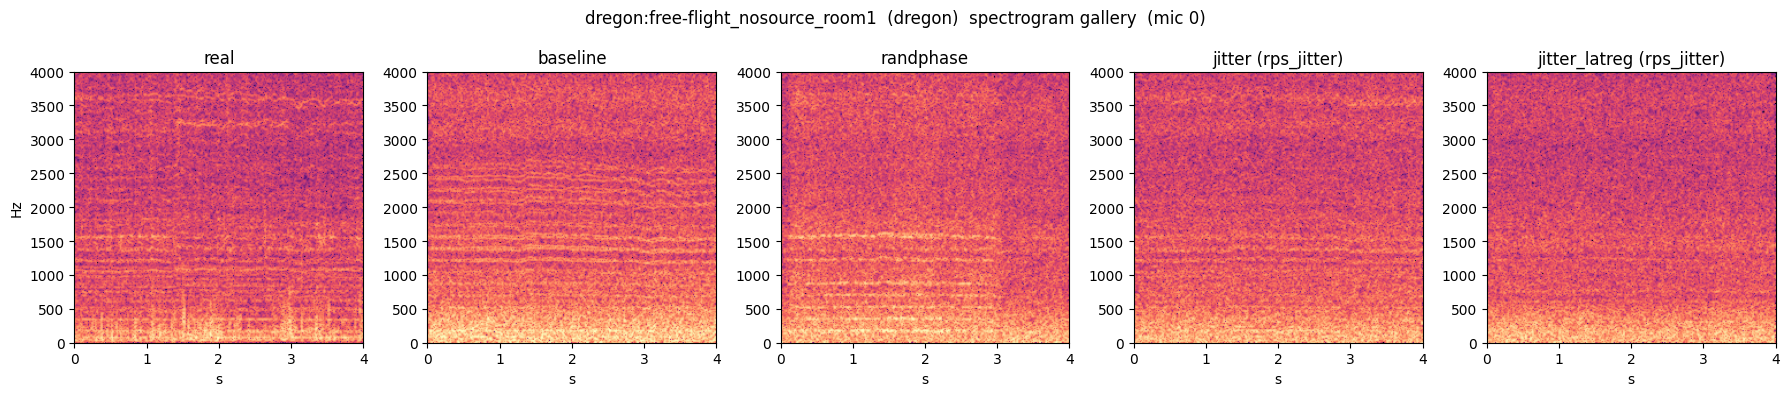

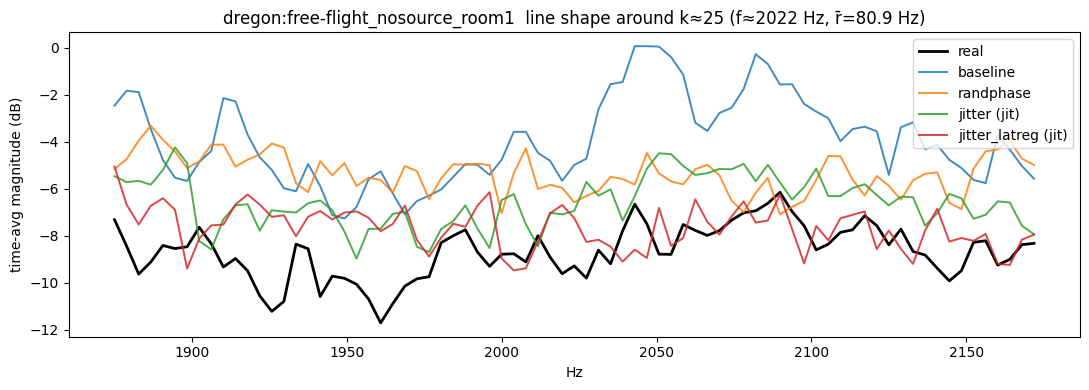


dregon:free-flight_nosource_room1  (dregon)  -  comb-masked mean |d log-mag| (dB) + msSTFT
variant          k<10    10-25    25-40   msSTFT
----------------------------------------------------
baseline        8.998    7.308    7.815    5.665
randphase       8.285    7.330    6.909    5.492
jitter          7.255    6.341    6.526    4.962
jitter_latreg    7.039    6.398    6.358    4.854


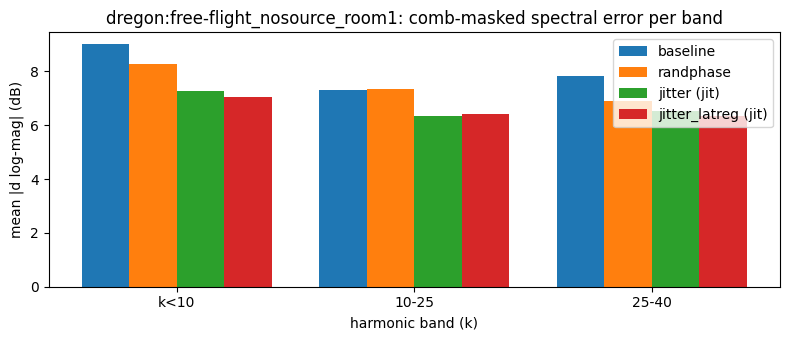

In [10]:
_ = run_comparison("dregon:free-flight_nosource_room1")

## Michael's FLY124 — held-out validation window (out-of-train)

FLY124's telemetry fully covers its val region; the throttle there is low
(r̄ ≈ 35 Hz), so harmonics are closely spaced but the RPS trajectory is
genuinely **out-of-train**.

michaels:FLY124: window [4.0, 8.0] s  rps mean = [31.3 36.1 41.  35.8]


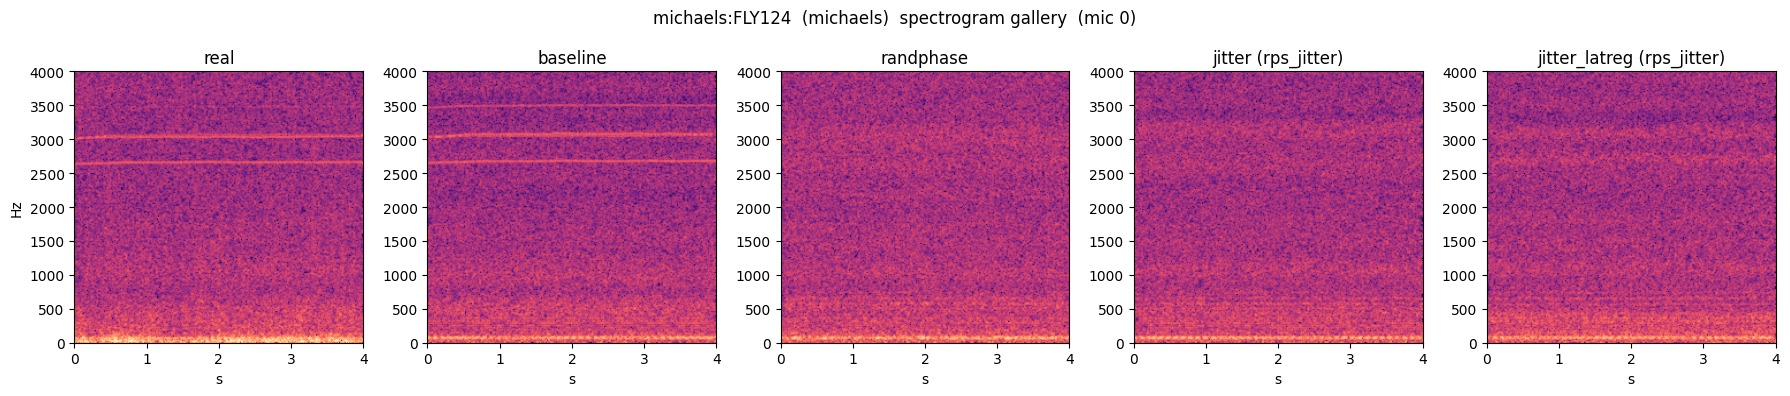

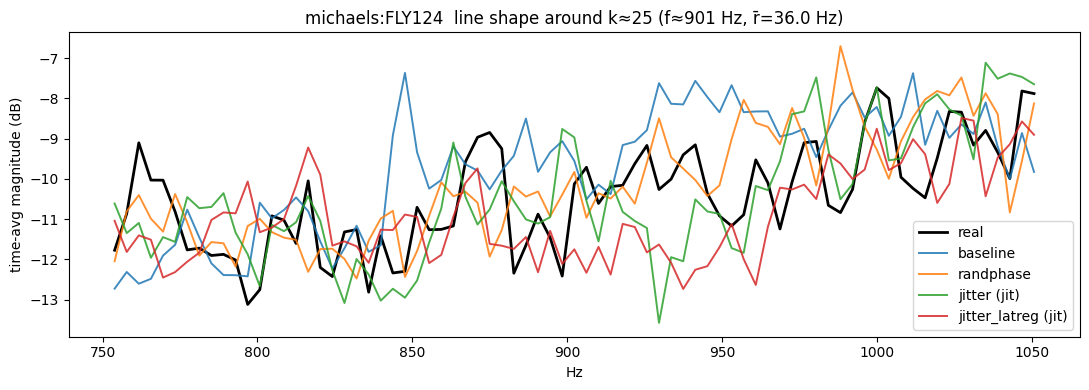


michaels:FLY124  (michaels)  -  comb-masked mean |d log-mag| (dB) + msSTFT
variant          k<10    10-25    25-40   msSTFT
----------------------------------------------------
baseline        7.352    6.186    5.999    4.365
randphase       7.254    6.305    6.070    4.497
jitter          7.465    6.221    6.180    4.401
jitter_latreg    7.297    6.344    6.156    4.458


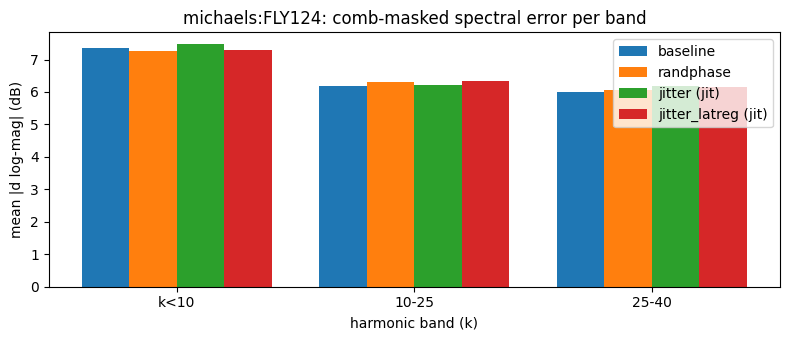

In [11]:
_ = run_comparison("michaels:FLY124")

## Interpretation (template — refine)

- **baseline** renders a *clean* comb: sharp lines that match the real
  fundamentals but cannot reproduce the real harmonics' finite width, so the
  loss under-weights the mid-k comb (the "washout").
- **randphase** replaces each line with a *constant-width* (~30 Hz) noise band
  regardless of harmonic order — it fills low-k gaps but over-broadens (and
  decoheres) the high-k comb where the real width is larger and still
  structured.
- **jitter (`rps_jitter=True`)** broadens each harmonic by ±k·σ Hz — a
  *coherent, frequency-proportional* width that tracks the real rotor jitter.
  Expect the largest comb-error reduction in the mid/high bands (10–25, 25–40),
  where baseline's clean lines and randphase's constant width both mismatch the
  real linewidth.
- The comb-masked table isolates this per band; msSTFT is the overall
  reference the arms were trained on.

_(Numbers fill in once the `baseline` and `jitter` checkpoints finish and the
notebook is re-run; today only the available arm(s) are shown.)_